In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import backtestPairs, calculatePairMetrics
# from MODELS.teamInfo import *


In [2]:
import joblib


# Load NGBoost mean and variance models
mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_25.pkl')
variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_25.pkl')
calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_25.pkl')

# mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_26.pkl')
# variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_26.pkl')
# calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_26.pkl')

models = {
    'mean': mean_model,
    'variance': variance_model,
    'calibration_factor': calibration_factor
}

features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

print(f"Loaded NGBoost models with calibration factor: {calibration_factor}")
print(f"Number of features: {len(features)}")

Loaded NGBoost models with calibration factor: 1
Number of features: 126


In [3]:
pd.set_option('display.max_columns', None)

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
# s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')
# df = s26
df = s25

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'underdog') &  (backtestData['CATEGORY'] == 'player_points')]
backtestData.sample(5)


C:\Users\alexg\AppData\Local\Temp\ipykernel_27528\1633982547.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
17659,17659,17659,17659,Scotty Pippen Jr,player_points,underdog,over,11.5,-137,Chicago Bulls,Memphis Grizzlies,ce345bbb3a55d78421626f5745a3307f,2024-11-24T01:10:00Z,2024-11-23,NaN,NaN,NaN,over
185629,185629,185629,104118,Dyson Daniels,player_points,underdog,over,13.5,-137,Orlando Magic,Atlanta Hawks,NaN,NaN,2025-04-08,game,14.5,-120.0,over
193765,193765,193765,114178,Lester Quinones,player_points,underdog,under,14.5,-137,New Orleans Pelicans,Miami Heat,NaN,NaN,2025-04-12,game,14.5,-108.0,under
145304,145304,145304,52213,Donovan Clingan,player_points,underdog,over,9.5,-137,Portland Trail Blazers,Memphis Grizzlies,NaN,NaN,2025-03-20,game,9.5,101.0,over
161879,161879,161879,73784,Dorian Finney-Smith,player_points,underdog,under,8.5,-137,Chicago Bulls,Los Angeles Lakers,NaN,NaN,2025-03-28,game,6.5,-123.0,under


In [95]:
# backtestData= pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/s26props.csv')
# s26_other = pd.read_csv('../DATA/CSV_FILES/PROP_DATA/PLAYER_LINES/NBA_DFS_20251106.csv')
# s26_other1 = pd.read_csv('../DATA/CSV_FILES/PROP_DATA/PLAYER_LINES/NBA_DFS_20251107.csv')
# backtestData = pd.concat([backtestData, s26_other, s26_other1])

# backtestData = backtestData[(backtestData['BOOKMAKER'] == 'Underdog') &  
#                             (backtestData['CATEGORY'] == 'player_points')]
# backtestData.rename(columns={'COMMENCE_TIME': 'GAME_DATE', 'OVER/UNDER': 'SIDE'}, inplace=True)
# backtestData

In [5]:
date = '2024-11-06'

results = backtestPairs(
    data=s25,
    backtestData=backtestData,
    gameDate=date,
    models=models,  
    features=features,
    edge_threshold=0.50, 
    top_n=10, 
    variance_inflation=1.1, 
    use_monte_carlo=True, n_simulations=10000, max_kelly=0.25, stake=10)


# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("PAIR BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['pair_profit'].sum() * 3
    avg_profit = results['pair_profit'].mean() * 3
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

Starting backtest for pairs on 2024-11-06
Time taken for pairs: 23.96993327140808 seconds
Time taken for sorting: 23.97294521331787 seconds
Time taken for dropping duplicates: 23.97545099258423 seconds
Time taken for iterating over evData: 23.97545099258423 seconds
Time taken for backtest_results: 23.98197913169861 seconds
PAIR BETTING RESULTS ANALYSIS
Total Bets: 10
Wins: 10
Win Rate: 100.00%
Total Profit: $600.00
Average Profit per Bet: $60.00


,NAME 1,NAME 2,LINE 1,LINE 2,PREDICTION 1,PREDICTION 2,MODEL SIDE 1,MODEL SIDE 2,PROB 1,PROB 2,PROB BOTH,EDGE 1,EDGE 2,COMBINED EDGE,EV$,KELLY FULL,RECOMMENDATION,INTERVAL WIDTH 1,INTERVAL WIDTH 2,SIGMA 1,SIGMA 2,SIGMA FLAG 1,SIGMA FLAG 2,EXPECTED ROI,SIMULATION METHOD,actual1,actual2,leg1_won,leg2_won,pair_won,pair_recommendation,pair_profit,selection,date
0,Jalen Brunson,Tyrese Maxey,28.5,27.5,22.01,21.05,under,under,0.893,0.899,0.9329,0.384,0.392,0.599,17.99,0.899,1,14.32,13.32,3.65,3.40,Low,Low,179.9,Monte Carlo,21,12,1,1,1,1,20.0,top_ev,2024-11-06
1,Jaylen Wells,Tyrese Maxey,10.5,27.5,14.59,21.05,over,under,0.864,0.899,0.9006,0.350,0.392,0.566,17.02,0.851,1,11.08,13.32,2.83,3.40,Low,Low,170.2,Monte Carlo,20,12,1,1,1,1,20.0,top_ev,2024-11-06
2,Jalen Brunson,Jaylen Wells,28.5,10.5,22.01,14.59,under,over,0.893,0.867,0.8961,0.384,0.354,0.562,16.88,0.844,1,14.32,11.08,3.65,2.83,Low,Low,168.8,Monte Carlo,21,20,1,1,1,1,20.0,top_ev,2024-11-06
3,Keldon Johnson,Tyrese Maxey,13.5,27.5,10.38,21.05,under,under,0.859,0.899,0.8950,0.345,0.392,0.561,16.85,0.843,1,8.58,13.32,2.19,3.40,Low,Low,168.5,Monte Carlo,10,12,1,1,1,1,20.0,top_ev,2024-11-06
4,Jalen Brunson,Keldon Johnson,28.5,13.5,22.01,10.38,under,under,0.893,0.857,0.8854,0.384,0.342,0.551,16.56,0.828,1,14.32,8.58,3.65,2.19,Low,Low,165.6,Monte Carlo,21,10,1,1,1,1,20.0,top_ev,2024-11-06
5,Tyler Herro,Tyrese Maxey,19.5,27.5,24.12,21.05,over,under,0.826,0.899,0.8574,0.306,0.392,0.523,15.72,0.786,1,15.48,13.32,3.95,3.40,Low,Low,157.2,Monte Carlo,28,12,1,1,1,1,20.0,top_ev,2024-11-06
6,Jaylen Wells,Keldon Johnson,10.5,13.5,14.59,10.38,over,under,0.864,0.857,0.8547,0.350,0.342,0.521,15.64,0.782,1,11.08,8.58,2.83,2.19,Low,Low,156.4,Monte Carlo,20,10,1,1,1,1,20.0,top_ev,2024-11-06
7,Kevin Durant,Tyrese Maxey,23.5,27.5,27.93,21.05,over,under,0.824,0.899,0.8543,0.303,0.392,0.520,15.63,0.781,1,15.09,13.32,3.85,3.40,Low,Low,156.3,Monte Carlo,32,12,1,1,1,1,20.0,top_ev,2024-11-06
8,Jalen Brunson,Tyler Herro,28.5,19.5,22.01,24.12,under,over,0.893,0.827,0.8510,0.384,0.307,0.517,15.53,0.776,1,14.32,15.48,3.65,3.95,Low,Low,155.3,Monte Carlo,21,28,1,1,1,1,20.0,top_ev,2024-11-06
9,Jalen Brunson,Kevin Durant,28.5,23.5,22.01,27.93,under,over,0.893,0.823,0.8467,0.384,0.302,0.513,15.40,0.770,1,14.32,15.09,3.65,3.85,Low,Low,154.0,Monte Carlo,21,32,1,1,1,1,20.0,top_ev,2024-11-06


## Points

In [8]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(
        data=s25,
        backtestData=backtestData,
        gameDate=date,
        models=models,  
        features=features,
        edge_threshold=0.60, 
        top_n=10, 
        variance_inflation=1.1, 
        use_monte_carlo=False, n_simulations=10000, max_kelly=0.25, stake=10)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-22... 1/163
Starting backtest for pairs on 2024-10-22
Time taken for pairs: 0.9217209815979004 seconds
Time taken for sorting: 0.9232313632965088 seconds
Time taken for dropping duplicates: 0.925238847732544 seconds
Time taken for iterating over evData: 0.925238847732544 seconds
Time taken for backtest_results: 0.9312474727630615 seconds
  ✓ Processed 10 bets
Processing 2024-10-23... 2/163
Starting backtest for pairs on 2024-10-23
Time taken for pairs: 12.925447940826416 seconds
Time taken for sorting: 12.92744779586792 seconds
Time taken for dropping duplicates: 12.929959774017334 seconds
Time taken for iterating over evData: 12.929959774017334 seconds
Time taken for backtest_results: 12.939987421035767 seconds
  ✓ Processed 16 bets
Processing 2024-10-24... 3/163
Starting backtest for pairs on 2024-10-24
Time taken for pairs: 2.9546730518341064 seconds
Time taken for sorting: 2.9556727409362793 seconds
Time taken for dropping duplicates: 2.956672191619873 seconds
Ti

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,388
   Wins: 531
   Hit Rate: 38.26%
   Total Profit: $2,050.00
   Total Staked: $13,880.00
   ROI: 14.77%
   Volatility: $86.33
   Max Drawdown: $-330.00
   Sharpe Ratio: 3.336

   PROBABILITY METRICS:
   Brier Score: 0.5307 (lower is better)
   Log Loss: 2.4784 (lower is better)
   AUC-ROC: 0.5778 (higher is better)
   Samples: 1388

 RECOMMENDED BETS ANALYSIS (Edge > 0.60):
   Total Bets: 891
   Wins: 376
   Hit Rate: 42.20%
   Total Profit: $2,370.00
   Total Staked: $8,910.00
   ROI: 26.60%
   Volatility: $79.29
   Max Drawdown: $-230.00
   Sharpe Ratio: 4.759


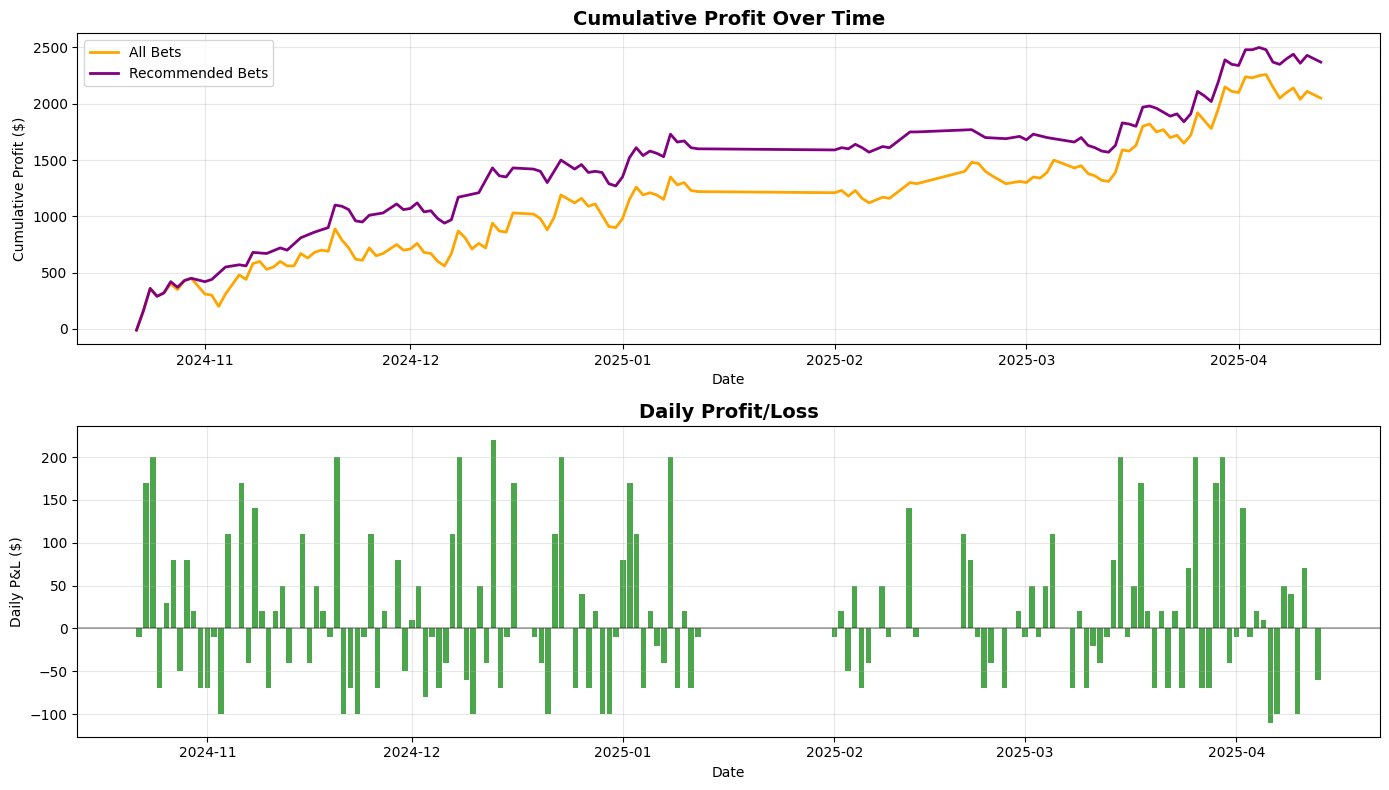

In [10]:
all_metrics = calculatePairMetrics(final_results, stake=10)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=10)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics
    if 'probability_metrics' in all_metrics and 'error' not in all_metrics['probability_metrics']:
        prob_metrics = all_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

if rec_metrics:
    print("\n RECOMMENDED BETS ANALYSIS (Edge > 0.60):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")
    
# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()